# Zajęcia 1: LLM i embeddingi

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/adrianstando/2026Z-PJATK-TEG/blob/main/01-llm-embeddingi/notebook.ipynb)

Zakres:
1. Konfiguracja dostępu do modelu.
2. Pierwsze wywołanie: system prompt i wiadomość użytkownika.
3. Zawartość odpowiedzi: tokeny, koszt, tokeny rozumowania.
4. Tokenizacja.
5. Parametry generowania: temperatura, `top_p`, limit długości.
6. Rozmowa z historią i prosty agent z narzędziami.
7. Embeddingi: podobieństwo, kontekst, klastry, analogie.
8. Mini-wyszukiwarka wektorowa, czyli podstawa RAG (zajęcia 2).

Komórki z tagiem `web:*` są pokazywane na prezentacji.

## 0. Instalacja i konfiguracja

In [1]:
# Colab / Deepnote / Codespaces: odkomentuj i uruchom raz
# %pip install -q openai tiktoken numpy scikit-learn matplotlib seaborn python-dotenv anthropic

Dostawcę wybiera się zmienną `LLM_PROVIDER` (plik `.env` albo w Colabie: ikona klucza → *Secrets*). Instrukcja konfiguracji dostępu: [00-dostep-do-llm](../00-dostep-do-llm/README.md).

| `LLM_PROVIDER` | Wymagania |
|---|---|
| `github` | `GITHUB_TOKEN` z uprawnieniem *Models: read*; darmowe, z dziennym limitem |
| `azure` | `AZURE_OPENAI_ENDPOINT`, `AZURE_OPENAI_API_KEY` i deploymenty modeli |
| `openai` | `OPENAI_API_KEY` |
| `deepseek` | `DEEPSEEK_API_KEY`; tanie API, bez embeddingów |
| `ollama` | lokalna [Ollama](https://ollama.com) z modelami `gemma4:e4b`, `gemma3:1b`, `embeddinggemma` |
| `proxy` | uruchomione [proxy dla subskrypcji](../tools/teg-proxy/README.md) (Copilot, Claude, Codex); bez embeddingów |

Wszyscy dostawcy udostępniają API zgodne z OpenAI, więc dalszy kod jest wspólny. Gdy dostawca nie liczy embeddingów, służy do tego `EMBED_PROVIDER` (domyślnie `ollama`).

In [2]:
import os

try:  # Colab: sekrety z panelu "Secrets"
    from google.colab import userdata
    for k in ["LLM_PROVIDER", "EMBED_PROVIDER", "GITHUB_TOKEN", "OPENAI_API_KEY", "AZURE_OPENAI_ENDPOINT",
              "AZURE_OPENAI_API_KEY", "DEEPSEEK_API_KEY", "ANTHROPIC_API_KEY"]:
        try:
            os.environ.setdefault(k, userdata.get(k))
        except Exception:
            pass
except ImportError:  # lokalnie: plik .env
    from dotenv import load_dotenv
    load_dotenv(override=True)

from openai import OpenAI, AzureOpenAI

# chat: model rozumujący, classic: model bez rozumowania, embed: model embeddingów.
# W Azure to NAZWY DEPLOYMENTÓW utworzonych w AI Foundry.
MODELS = {
    "github":   {"chat": "openai/gpt-5-nano", "classic": "openai/gpt-4.1-mini", "embed": "openai/text-embedding-3-small"},
    "openai":   {"chat": "gpt-5-nano", "classic": "gpt-4.1-mini", "embed": "text-embedding-3-small"},
    "azure":    {"chat": "gpt-5-nano", "classic": "gpt-4o-mini", "embed": "text-embedding-3-small"},
    "deepseek": {"chat": "deepseek-reasoner", "classic": "deepseek-chat", "embed": None},
    "ollama":   {"chat": "gemma4:e4b", "classic": "gemma3:1b", "embed": "embeddinggemma"},
    "proxy":    {"chat": "copilot/gpt-5-mini", "classic": "copilot/gpt-5-mini", "embed": None},
}

def make_client(provider):
    if provider == "github":
        return OpenAI(base_url="https://models.github.ai/inference", api_key=os.environ["GITHUB_TOKEN"])
    if provider == "azure":
        return AzureOpenAI(api_version="2024-12-01-preview")  # AZURE_OPENAI_ENDPOINT + AZURE_OPENAI_API_KEY
    if provider == "deepseek":
        return OpenAI(base_url="https://api.deepseek.com", api_key=os.environ["DEEPSEEK_API_KEY"])
    if provider == "ollama":
        return OpenAI(base_url="http://localhost:11434/v1", api_key="ollama")  # klucz wymagany, ale ignorowany
    if provider == "proxy":
        return OpenAI(base_url="http://localhost:8787/v1", api_key="teg")
    return OpenAI()  # OPENAI_API_KEY

PROVIDER = os.getenv("LLM_PROVIDER", "github")
EMBED_PROVIDER = os.getenv("EMBED_PROVIDER") or (PROVIDER if MODELS[PROVIDER]["embed"] else "ollama")

client = make_client(PROVIDER)
embed_client = client if EMBED_PROVIDER == PROVIDER else make_client(EMBED_PROVIDER)
CHAT, CLASSIC = MODELS[PROVIDER]["chat"], MODELS[PROVIDER]["classic"]
EMBED = MODELS[EMBED_PROVIDER]["embed"]
print(f"czat: {PROVIDER} ({CHAT}, klasyczny: {CLASSIC}) | embeddingi: {EMBED_PROVIDER} ({EMBED})")

czat: ollama (gemma4:e4b, klasyczny: gemma3:1b) | embeddingi: ollama (embeddinggemma)


`CHAT` to model **rozumujący**: przed odpowiedzią generuje ukryte tokeny rozumowania. `CLASSIC` to model bez rozumowania. Różnica ma znaczenie przy parametrach generowania (sekcja 4).

## 1. Pierwsze wywołanie

Rozmowa to lista wiadomości z rolami:
- `system`: instrukcja dla modelu (rola, ton, format odpowiedzi),
- `user`: wiadomość użytkownika,
- `assistant`: wcześniejsze odpowiedzi modelu.

In [3]:
response = client.chat.completions.create(
    model=CHAT,
    messages=[
        {"role": "system", "content": "You are a cool teacher who explains science using hip-hop slang."},
        {"role": "user", "content": "Why is the sky blue?"},
    ],
)
print(response.choices[0].message.content)

**(Sound of a scratchy needle dropping, followed by a deep, rhythmic beat dropping.)**

Yo, what up! Pull up a seat, 'cause we 'bout to drop some truth bombs on some cosmic chemistry. You wanna know why the sky drippin' that blue vibe? Word. This ain't magic, fam, this is pure *physics*, and I'm 'bout to break it down so hard, you gon' feel the knowledge flow.

Listen close, 'cause this lesson is grade-A banger.

### 🎤 The Setup: The OG Beam

First off, you gotta understand the source. That light blasting down from the sun? It ain't just *one* color, nah mean? That light is a full spectrum, baby. It's got the whole rainbow crew rocking with it—the reds, the oranges, the yellows, the greens, and all the blues. It's a mixtape of energy, straight fire.

### 💨 The Venue: The Air Circuit

Now, the Earth ain't empty space, nah. We got this whole atmosphere—a giant molecular squad of gas atoms, mostly Nitrogen and Oxygen, pumpin' vibes all the time. These atoms are tiny, but they are *key*. T

**Ćwiczenie.** Zmień system prompt (pirat, konsultant korporacyjny, przedszkolanka) i porównaj odpowiedzi na to samo pytanie. Następnie wymuś format: *„Odpowiadaj wyłącznie w JSON z polami `answer` i `confidence`”*.

## 2. Zawartość odpowiedzi

Odpowiedź to obiekt, a nie sam tekst. Najważniejsze pola:
- `choices[0].message.content`: treść,
- `choices[0].finish_reason`: `stop` (koniec odpowiedzi) albo `length` (wyczerpany limit tokenów),
- `usage`: zużycie tokenów, czyli podstawa rozliczenia.

In [4]:
u = response.usage
print("finish_reason:     ", response.choices[0].finish_reason)
print("prompt tokens:     ", u.prompt_tokens)
print("completion tokens: ", u.completion_tokens)
details = getattr(u, "completion_tokens_details", None)
print("reasoning tokens:  ", getattr(details, "reasoning_tokens", None))

finish_reason:      stop
prompt tokens:      35
completion tokens:  1210
reasoning tokens:   None


W modelach rozumujących `completion_tokens` obejmuje także tokeny rozumowania, których nie widać w odpowiedzi. Przykład z `gpt-5-nano` dla tego samego pytania: 847 tokenów odpowiedzi, z czego 576 to rozumowanie. Rozliczane są wszystkie. Nie każdy dostawca raportuje `reasoning_tokens` (np. Ollama zwraca `None`).

## 3. Tokeny

Model nie przetwarza liter ani słów, tylko **tokeny**: fragmenty tekstu ze słownika tokenizera. Modele GPT-4o i GPT-5 używają tokenizera `o200k_base` (ok. 200 tys. tokenów). Słownik powstał na korpusie zdominowanym przez angielski, dlatego angielskie słowa częściej są pojedynczymi tokenami, a polski tekst dzieli się na więcej fragmentów. Ten sam tekst po polsku jest droższy i zajmuje więcej miejsca w oknie kontekstu.

In [5]:
import tiktoken

enc = tiktoken.get_encoding("o200k_base")
for text in ["Language models predict the next token.",
             "Modele językowe przewidują kolejny token.",
             "Konstantynopolitańczykowianeczka"]:
    ids = enc.encode(text)
    pieces = [enc.decode([i]) for i in ids]
    print(f"{len(text):3d} znaków -> {len(ids):2d} tokenów | {pieces}")

 39 znaków ->  7 tokenów | ['Language', ' models', ' predict', ' the', ' next', ' token', '.']
 41 znaków -> 12 tokenów | ['Mode', 'le', ' ję', 'zyk', 'owe', ' przew', 'id', 'ują', ' kolej', 'ny', ' token', '.']
 32 znaków -> 10 tokenów | ['Kon', 'stant', 'yn', 'opol', 'ita', 'ńczy', 'kow', 'ian', 'ecz', 'ka']


**Ćwiczenie.** Policz tokeny dla własnego imienia i nazwiska, fragmentu kodu w Pythonie i emoji 🙂. Który tekst jest najdroższy w przeliczeniu na znak?

## 4. Parametry generowania

W każdym kroku model wyznacza rozkład prawdopodobieństwa kolejnego tokenu i z niego losuje. Parametry zmieniają ten rozkład:
- `temperature`: mała wartość wyostrza rozkład (prawie zawsze najbardziej prawdopodobny token), duża go spłaszcza,
- `top_p`: losowanie tylko spośród najbardziej prawdopodobnych tokenów, których łączne prawdopodobieństwo wynosi `p`,
- `top_k` (Ollama, Anthropic; brak w API OpenAI): losowanie tylko spośród `k` najbardziej prawdopodobnych tokenów.

Zalecenie OpenAI: zmieniać **albo** `temperature`, **albo** `top_p`. Interaktywna wersja wszystkich trzech parametrów jest na prezentacji.

> **Uwaga.** Modele rozumujące (gpt-5*, seria o, Claude Opus 5.5) nie przyjmują `temperature` ani `top_p` i zwracają błąd 400. Poniżej używany jest więc `CLASSIC`.

In [6]:
for temp in [0.0, 1.0, 1.6]:
    out = client.chat.completions.create(
        model=CLASSIC,
        messages=[{"role": "user", "content": "Describe a sunset in one creative sentence."}],
        temperature=temp,
    )
    print(f"T={temp}: {out.choices[0].message.content.strip()}\n")

T=0.0: The sky bled into a molten tapestry of fire and amethyst, whispering a final, breathtaking farewell to the day.



T=1.0: The sky bled a bruised and glorious purple, melting into fiery gold and finally, a whispered twilight promise.



T=1.6: The sky bled into a fiery, pulsing heart, dissolving into a velvet ocean of amber and rose.



Po kilkukrotnym uruchomieniu komórki: przy `T=0` odpowiedzi są (prawie) identyczne, przy `T=1.6` za każdym razem inne, a czasem bez sensu.

Ta sama próba z modelem rozumującym:

In [7]:
try:
    client.chat.completions.create(model=CHAT, messages=[{"role": "user", "content": "Hi"}], temperature=0.2)
    print(f"{CHAT}: temperature przyjęte.")
except Exception as e:
    print(type(e).__name__, "->", str(e)[:200])

gemma4:e4b: temperature przyjęte.


### Limit długości odpowiedzi

Limit tokenów ucina odpowiedź. Model nie wie o limicie, więc nie skraca odpowiedzi, tylko zostaje przerwany (`finish_reason == "length"`). Krótszą odpowiedź lepiej uzyskać instrukcją w prompcie.

W modelach rozumujących limit obejmuje **również tokeny rozumowania**. Przy zbyt niskim limicie rozumowanie może go wyczerpać, zanim powstanie jakakolwiek treść, i odpowiedź będzie pusta. Nowsze modele same dobierają długość rozumowania do trudności zadania (*adaptive thinking* w Claude, *reasoning effort* w GPT-5), ale limit nadal liczy wszystkie tokeny.

Nazwa parametru zależy od API:

| API | Parametr |
|---|---|
| OpenAI Chat Completions (także Azure, GitHub Models) | `max_completion_tokens` (stary `max_tokens` jest odrzucany przez modele rozumujące) |
| OpenAI Responses API | `max_output_tokens` |
| Anthropic | `max_tokens` (wymagany) |
| Ollama (API zgodne z OpenAI) | `max_tokens`; `max_completion_tokens` jest ignorowany |

In [8]:
LIMIT_PARAM = "max_tokens" if PROVIDER == "ollama" else "max_completion_tokens"

for limit in [15, 1000]:
    out = client.chat.completions.create(
        model=CHAT,
        messages=[{"role": "user", "content": "Explain machine learning in two sentences."}],
        **{LIMIT_PARAM: limit},
    )
    c = out.choices[0]
    print(f"limit={limit:5d} finish_reason={c.finish_reason:7s} tokeny={out.usage.completion_tokens:4d} | {c.message.content!r:.120}")

limit=   15 finish_reason=length  tokeny=  15 | 'Machine learning enables computers to learn patterns and make predictions directly from data, rather'


limit= 1000 finish_reason=stop    tokeny= 299 | 'Machine learning is a form of artificial intelligence that enables computer systems to learn from data by identifying c


## 5. Rozmowa z historią

API jest **bezstanowe**: model nie pamięta poprzednich wywołań. Pamięć rozmowy to lista wiadomości, którą przy każdym wywołaniu trzeba wysłać od nowa. Z tego powodu długa rozmowa kosztuje coraz więcej.

In [9]:
history = [{"role": "system", "content": "Jesteś asystentem na zajęciach z AI. Odpowiadasz krótko, po polsku."}]

def chat(user_message):
    history.append({"role": "user", "content": user_message})
    reply = client.chat.completions.create(model=CHAT, messages=history).choices[0].message.content
    history.append({"role": "assistant", "content": reply})
    return reply

print(chat("Cześć, mam na imię Ola i interesują mnie grafy wiedzy."))
print(chat("Jak mam na imię i co mnie interesuje?"))
print(f"\nwiadomości w historii: {len(history)}")

Cześć Ola! Grafy wiedzy to bardzo ciekawy temat. Chętnie Ci w tym pomogę. 😊


Masz na imię Ola i interesują Cię grafy wiedzy.

wiadomości w historii: 5


## 6. Prosty agent

Model nie zna dzisiejszej daty i nie liczy niezawodnie. Może jednak poprosić o wywołanie funkcji (*tool calling*): zwraca nazwę funkcji i argumenty, a kod je wykonuje i odsyła wynik. Agent to pętla: model → narzędzie → model, dopóki model nie odpowie tekstem.

Więcej o agentach na zajęciach 3.

In [10]:
import json
from datetime import date

def get_today() -> str:
    return date.today().isoformat()

def days_between(start: str, end: str) -> int:
    return (date.fromisoformat(end) - date.fromisoformat(start)).days

TOOLS = {"get_today": get_today, "days_between": days_between}
TOOL_SPECS = [
    {"type": "function", "function": {"name": "get_today", "description": "Dzisiejsza data (YYYY-MM-DD).",
                                      "parameters": {"type": "object", "properties": {}}}},
    {"type": "function", "function": {"name": "days_between", "description": "Liczba dni między datami (YYYY-MM-DD).",
                                      "parameters": {"type": "object", "properties": {"start": {"type": "string"}, "end": {"type": "string"}},
                                                     "required": ["start", "end"]}}},
]

def agent(question, max_steps=5):
    messages = [{"role": "user", "content": question}]
    for step in range(1, max_steps + 1):
        msg = client.chat.completions.create(model=CHAT, messages=messages, tools=TOOL_SPECS).choices[0].message
        if not msg.tool_calls:          # model odpowiada tekstem: koniec pętli
            return msg.content
        messages.append(msg.model_dump(exclude_none=True))
        for call in msg.tool_calls:     # model prosi o narzędzia: wykonanie i odesłanie wyników
            args = json.loads(call.function.arguments or "{}")
            result = TOOLS[call.function.name](**args)
            print(f"krok {step}: {call.function.name}({args}) -> {result}")
            messages.append({"role": "tool", "tool_call_id": call.id, "content": str(result)})
    return "Przekroczono limit kroków."

print(agent("Ile dni zostało do Wigilii 2026?"))

krok 1: get_today({}) -> 2026-10-01


krok 2: days_between({'end': '2026-12-24', 'start': '2026-10-01'}) -> 84


Do Wigilii 2026 pozostało **84 dni**.


## 7. Inny dostawca: Anthropic (Claude)

API Anthropic ma inny kształt: `system` jest osobnym parametrem, `max_tokens` jest wymagany, a treść odpowiedzi znajduje się w `content[0].text`. Komórka wykona się tylko przy ustawionym `ANTHROPIC_API_KEY`. Pozostałe przykłady (Claude Agent SDK, Codex, Copilot SDK) są w [00-dostep-do-llm](../00-dostep-do-llm/README.md).

In [11]:
if os.getenv("ANTHROPIC_API_KEY"):
    import anthropic

    claude = anthropic.Anthropic()
    msg = claude.messages.create(
        model="claude-opus-5-5",
        max_tokens=1024,
        system="You are a cool teacher who explains science using hip-hop slang.",
        messages=[{"role": "user", "content": "Why is the sky blue?"}],
    )
    print(msg.content[0].text)
    print(msg.usage)
else:
    print("Brak ANTHROPIC_API_KEY, komórka pominięta.")

Brak ANTHROPIC_API_KEY, komórka pominięta.


---
# Embeddingi

Model embeddingów zamienia tekst na wektor liczb o stałej długości. Teksty o podobnym znaczeniu dają wektory skierowane w podobną stronę. Na tym opiera się wyszukiwanie semantyczne, RAG, rekomendacje i klasteryzacja.

| Model | Dostawca | Wymiar |
|---|---|---|
| `text-embedding-3-small` | OpenAI / Azure / GitHub Models | 1536 |
| `embeddinggemma` | Ollama (lokalnie) | 768 |

In [12]:
import numpy as np

_cache = {}

def embed(texts):
    """Embeddingi dla listy tekstów (z cache, żeby nie płacić dwa razy za to samo)."""
    todo = [t for t in texts if t not in _cache]
    if todo:
        resp = embed_client.embeddings.create(model=EMBED, input=todo)
        for t, d in zip(todo, resp.data):
            _cache[t] = np.array(d.embedding)
    return np.array([_cache[t] for t in texts])

def get_embedding(text):
    return embed([text])[0]

v = get_embedding("cat")
print("wymiar:        ", len(v))
print("pierwsze 5:    ", np.round(v[:5], 4))
print("długość (norm):", round(float(np.linalg.norm(v)), 4))

wymiar:         768
pierwsze 5:     [-0.2113  0.0116  0.0427  0.0268  0.0036]
długość (norm): 1.0


Długość wektora wynosi 1, bo dostawcy normalizują embeddingi. Dla takich wektorów cosinus jest równy iloczynowi skalarnemu (`a @ b`), a odległość euklidesowa niesie tę samą informację: kwadrat odległości to `2 − 2·cos(a, b)`.

## 8. Miary podobieństwa

In [13]:
def cos(a, b):
    a, b = np.asarray(a), np.asarray(b)
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

pairs = [("cat", "dog"), ("cat", "kitten"), ("king", "queen"), ("man", "woman"),
         ("happy", "joyful"), ("car", "automobile"), ("bratwurst", "sushi")]
print(f"{'para':<20}{'cosinus':>9}{'iloczyn':>9}{'euklides':>10}")
for a, b in pairs:
    va, vb = get_embedding(a), get_embedding(b)
    print(f"{a + ' - ' + b:<20}{cos(va, vb):>9.4f}{va @ vb:>9.4f}{np.linalg.norm(va - vb):>10.4f}")

para                  cosinus  iloczyn  euklides


cat - dog              0.7570   0.7570    0.6971


cat - kitten           0.8856   0.8856    0.4784


king - queen           0.7331   0.7331    0.7306


man - woman            0.7162   0.7162    0.7534


happy - joyful         0.9285   0.9285    0.3782


car - automobile       0.9145   0.9145    0.4135


bratwurst - sushi      0.6410   0.6410    0.8473


Nawet „bratwurst” i „sushi” mają dodatni cosinus. W praktyce liczy się **ranking** (co jest bliżej czego), a nie konkretna wartość, która zależy od modelu.

## 9. Kontekst

Porównanie: słowo „cat” samo i w zdaniach. W `text-embedding-3-small` (OpenAI) samo słowo „cat” jest bliżej „dog” niż „kitten”, a dopiero kontekst odwraca kolejność. Wynik dla bieżącego modelu poniżej.

In [14]:
templates = ["{}", "The {} is sleeping peacefully", "I love my {} very much", "Training a {} requires patience"]
print(f"{'kontekst':<34}{'cat-dog':>9}{'cat-kitten':>12}")
for t in templates:
    c, d, k = embed([t.format(w) for w in ["cat", "dog", "kitten"]])
    print(f"{t.replace('{}', '[X]'):<34}{cos(c, d):>9.4f}{cos(c, k):>12.4f}")

kontekst                            cat-dog  cat-kitten
[X]                                  0.7570      0.8856


The [X] is sleeping peacefully       0.7930      0.9157


I love my [X] very much              0.8758      0.9531


Training a [X] requires patience     0.8341      0.9408


Wnioski:
- relacje między słowami zależą od modelu: embedding odzwierciedla użycie słów w danych treningowych konkretnego modelu,
- zmiana modelu oznacza ponowne policzenie embeddingów całej bazy,
- w RAG embeddingi liczy się dla **fragmentów tekstu** (chunków), a nie pojedynczych słów.

## 10. Klastry: rzut na 2D

Wektora o 768 czy 1536 wymiarach nie da się narysować, dlatego rzutuje się go na 2D:
- **PCA**: rzut liniowy; szybki, ale zwykle zachowuje niewielką część wariancji, więc grupy się nakładają,
- **t-SNE**: rzut nieliniowy; zachowuje sąsiedztwa i dobrze pokazuje klastry, ale **odległości między klastrami i ich rozmiary nie mają znaczenia**.

Podobieństwo liczy się zawsze na **pełnych wektorach**. Rzut 2D służy wyłącznie do wizualizacji.

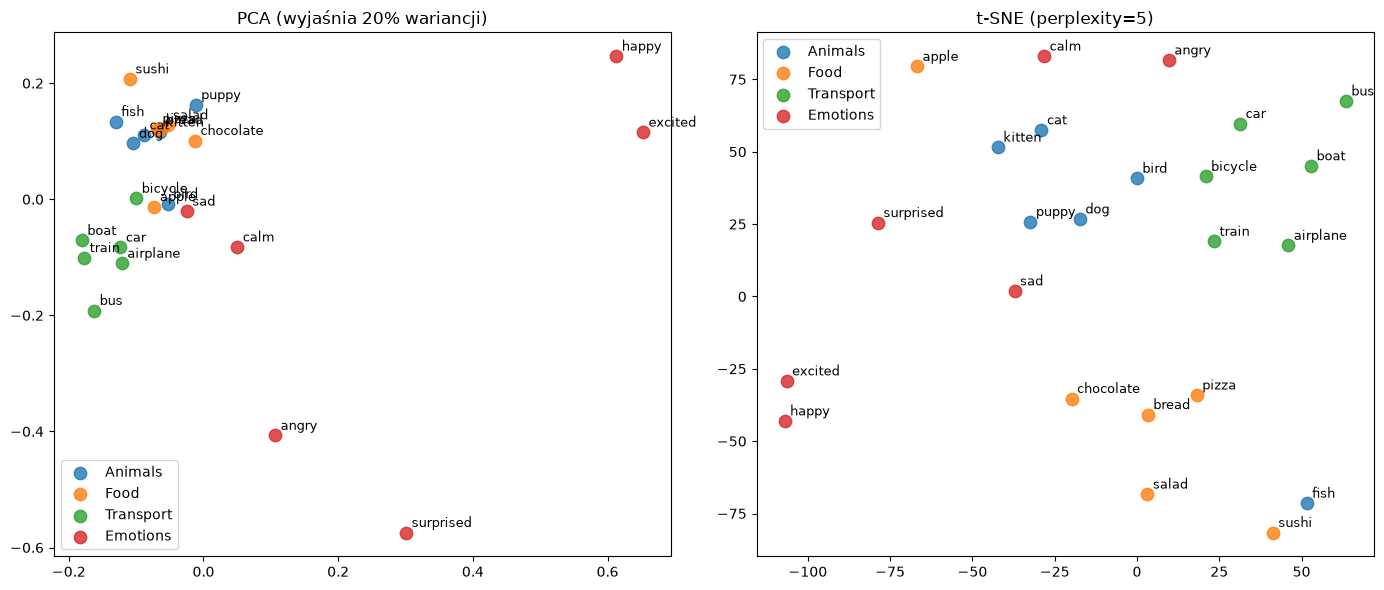

In [15]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

groups = {
    "Animals": ["cat", "dog", "kitten", "puppy", "bird", "fish"],
    "Food": ["apple", "pizza", "sushi", "bread", "chocolate", "salad"],
    "Transport": ["car", "bicycle", "airplane", "train", "boat", "bus"],
    "Emotions": ["happy", "sad", "angry", "excited", "calm", "surprised"],
}
words = [w for ws in groups.values() for w in ws]
labels = [g for g, ws in groups.items() for _ in ws]
X = embed(words)

pca = PCA(n_components=2).fit(X)
projections = {
    f"PCA (wyjaśnia {pca.explained_variance_ratio_.sum():.0%} wariancji)": pca.transform(X),
    "t-SNE (perplexity=5)": TSNE(n_components=2, perplexity=5, metric="cosine", init="pca", random_state=0).fit_transform(X),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (title, P) in zip(axes, projections.items()):
    for g in groups:
        idx = [i for i, l in enumerate(labels) if l == g]
        ax.scatter(P[idx, 0], P[idx, 1], s=80, alpha=0.8, label=g)
        for i in idx:
            ax.annotate(words[i], P[i], fontsize=9, xytext=(4, 4), textcoords="offset points")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import silhouette_score

S = X @ X.T  # wektory znormalizowane, więc to macierz cosinusów
same = [S[i, j] for i in range(len(words)) for j in range(i + 1, len(words)) if labels[i] == labels[j]]
diff = [S[i, j] for i in range(len(words)) for j in range(i + 1, len(words)) if labels[i] != labels[j]]
print(f"średni cosinus w tej samej grupie: {np.mean(same):.3f}")
print(f"średni cosinus między grupami:     {np.mean(diff):.3f}")
print(f"silhouette (pełne wektory, cos):   {silhouette_score(X, labels, metric='cosine'):.3f}")

średni cosinus w tej samej grupie: 0.615
średni cosinus między grupami:     0.558
silhouette (pełne wektory, cos):   0.027


## 11. Mapa podobieństw

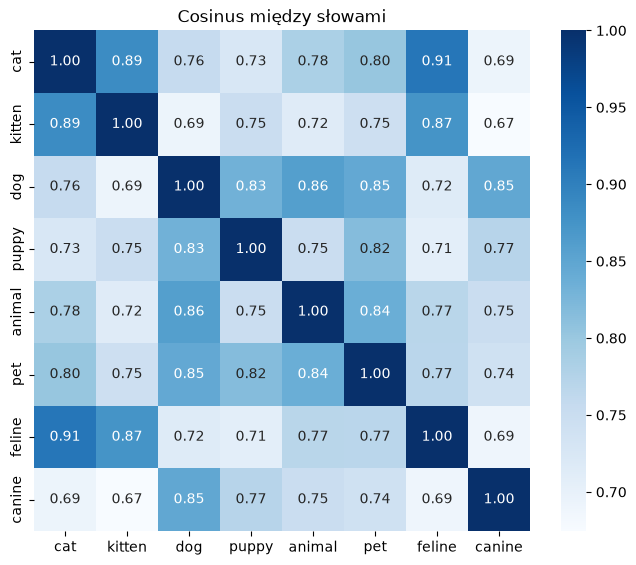

In [17]:
import seaborn as sns

hw = ["cat", "kitten", "dog", "puppy", "animal", "pet", "feline", "canine"]
H = embed(hw)
plt.figure(figsize=(8, 6.5))
sns.heatmap(H @ H.T, annot=True, fmt=".2f", xticklabels=hw, yticklabels=hw, cmap="Blues")
plt.title("Cosinus między słowami")
plt.show()

## 12. Arytmetyka wektorów: king − man + woman ≈ queen?

Klasyczny przykład z word2vec. W nowszych modelach działa słabiej, niż sugerują podręczniki: najbliżej wyniku jest zwykle jedno ze słów wejściowych („king”), dlatego standardowo wyklucza się je z rankingu.

In [18]:
def analogy(a, b, c, candidates):
    """a - b + c ≈ ?  (np. king - man + woman)"""
    target = get_embedding(a) - get_embedding(b) + get_embedding(c)
    return sorted(((w, cos(target, get_embedding(w))) for w in candidates), key=lambda x: -x[1])

cands = ["queen", "king", "woman", "princess", "lady", "ruler", "empress", "monarch", "prince"]
for w, s in analogy("king", "man", "woman", cands):
    flag = "  <- słowo wejściowe" if w in {"king", "woman"} else ""
    print(f"{w:<10}{s:.4f}{flag}")

king      0.7640  <- słowo wejściowe
queen     0.7031
woman     0.6594  <- słowo wejściowe
lady      0.5894
princess  0.5749
monarch   0.5267
ruler     0.5033
prince    0.4490
empress   0.3281


## 13. Mini-wyszukiwarka wektorowa

Tak działa każda baza wektorowa, tylko bez optymalizacji:
1. embedding dokumentów (raz),
2. embedding zapytania,
3. cosinus z **każdym** dokumentem i wybór `k` najlepszych.

Bazy wektorowe (Chroma, FAISS, pgvector) zastępują krok 3 przybliżonym wyszukiwaniem (ANN), żeby nie porównywać zapytania z milionem wektorów po kolei.

In [19]:
docs = [
    "Maria Skłodowska-Curie jako pierwsza osoba otrzymała dwie Nagrody Nobla w dwóch różnych dziedzinach.",
    "Skłodowska odkryła polon i rad, a polon nazwała na cześć Polski.",
    "Einstein sformułował szczególną teorię względności w 1905 roku.",
    "Równanie E = mc² opisuje równoważność masy i energii.",
    "Newton opisał prawo powszechnego ciążenia i trzy zasady dynamiki.",
    "Ada Lovelace napisała pierwszy algorytm przeznaczony dla maszyny analitycznej Babbage'a.",
    "Darwin opisał ewolucję drogą doboru naturalnego w dziele O powstawaniu gatunków.",
    "Darwin przez lata badał dżdżownice i ich wpływ na glebę.",
]
D = embed(docs)

def search(query, k=3):
    q = get_embedding(query)
    scores = D @ q / (np.linalg.norm(D, axis=1) * np.linalg.norm(q))
    best = np.argsort(-scores)[:k]
    return [(round(float(scores[i]), 3), docs[i]) for i in best]

for q in ["Kto dostał dwa Noble?", "Dlaczego jabłko spada na ziemię?"]:
    print("Q:", q)
    for s, d in search(q):
        print(f"   {s:.3f}  {d}")

Q: Kto dostał dwa Noble?


   0.522  Maria Skłodowska-Curie jako pierwsza osoba otrzymała dwie Nagrody Nobla w dwóch różnych dziedzinach.
   0.270  Newton opisał prawo powszechnego ciążenia i trzy zasady dynamiki.
   0.213  Skłodowska odkryła polon i rad, a polon nazwała na cześć Polski.
Q: Dlaczego jabłko spada na ziemię?


   0.416  Darwin przez lata badał dżdżownice i ich wpływ na glebę.
   0.322  Darwin opisał ewolucję drogą doboru naturalnego w dziele O powstawaniu gatunków.
   0.314  Newton opisał prawo powszechnego ciążenia i trzy zasady dynamiki.


W drugim pytaniu Newton nie musi być na pierwszym miejscu. Model embeddingów łączy podobne słowa („ziemia” i „gleba”), ale nie rozumie pytania. Na zajęciach 2 pojawią się poprawki:
- **wyszukiwanie hybrydowe**: embeddingi + BM25 (słowa kluczowe),
- **reranking**: drugi model ocenia pary (pytanie, fragment).

**Ćwiczenie.** Dopisz 5 dokumentów i 3 pytania z wybranej dziedziny. Znajdź pytanie, na które wyszukiwarka odpowiada źle, i wyjaśnij, dlaczego.

## Zadanie

Zadanie po zajęciach: [zadanie.ipynb](zadanie.ipynb) ([Colab](https://colab.research.google.com/github/adrianstando/2026Z-PJATK-TEG/blob/main/01-llm-embeddingi/zadanie.ipynb)).